<a href="https://colab.research.google.com/github/edgaryoungpilo-web/colab-files/blob/main/Practica_23_266659.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Arbol de desicion para regresion

In [2]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

# Cargar dataset
data = fetch_california_housing()

# Convertir a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

# Mostrar primeras filas
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Estructura del Dataset

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# Distribucion de la variable

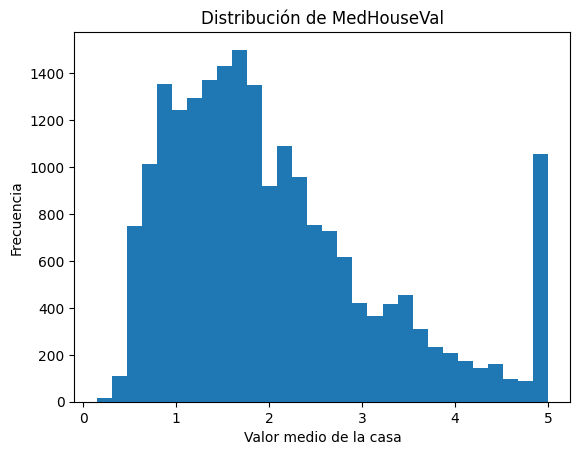

In [4]:
plt.figure()
plt.hist(df['MedHouseVal'], bins=30)
plt.title('Distribución de MedHouseVal')
plt.xlabel('Valor medio de la casa')
plt.ylabel('Frecuencia')
plt.show()

Interpretacion:

La variable objetivo presentauna distribucion sesgada hacia la derecha lo que lo que indica que existen mas valores bajos-medios que altos.

# Preparacion de datos

In [5]:
from sklearn.model_selection import train_test_split

# Variables
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# División
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


# Modelo Base

In [6]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Modelo
model = DecisionTreeRegressor(max_depth=None, random_state=42)
model.fit(X_train, y_train)

# Predicciones
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Métricas
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)
print("Train R2:", r2_train)
print("Test R2:", r2_test)

Train RMSE: 3.218325866275131e-16
Test RMSE: 0.7037294974840077
Train R2: 1.0
Test R2: 0.622075845135081


Interpretacion:


*   Si el error en entrenaminto es muy bajo pero en prueba alto - sobreajuste
*   por lo regular aqui se observa:


      1.   R^2 entenamiento = 1
      2.   R^2 prueba significativamente menor


*   Conclusion: si hay sobreajuste







# Analisis Bias-Variance

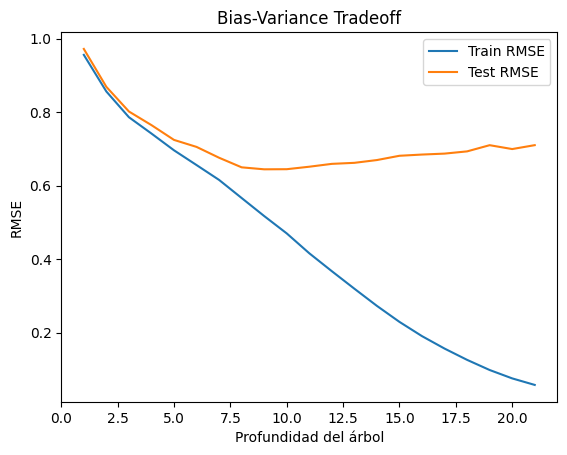

In [7]:
depths = range(1, 22)
rmse_train_list = []
rmse_test_list = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    rmse_train_list.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    rmse_test_list.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

# Gráfica
plt.figure()
plt.plot(depths, rmse_train_list, label='Train RMSE')
plt.plot(depths, rmse_test_list, label='Test RMSE')
plt.xlabel('Profundidad del árbol')
plt.ylabel('RMSE')
plt.title('Bias-Variance Tradeoff')
plt.legend()
plt.show()

Interpretacion:


*   Profundidad baja: alto bias
*   Profundidad alto: alta varianza
*   El menor punto esta donde el RMSE de prueba es minimo






# Poda del arbol

In [ ]:
# Obtener alphas
path = DecisionTreeRegressor(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Tomar algunos valores
ccp_alphas = ccp_alphas[::5]

rmse_test_alpha = []

for alpha in ccp_alphas:
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)

    y_test_pred = model.predict(X_test)
    rmse_test_alpha.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

# Gráfica
plt.figure()
plt.plot(ccp_alphas, rmse_test_alpha)
plt.xlabel('ccp_alpha')
plt.ylabel('RMSE Test')
plt.title('Efecto de la poda')
plt.show()

Interpretacion:


*   Valores pequeños: Arbol complejo
*   Valores grandes: Arbol simple
*   Existe un punto





# Importancia de variables

In [ ]:
# Entrenar modelo final (puedes elegir mejor profundidad o alpha)
final_model = DecisionTreeRegressor(max_depth=5, random_state=42)
final_model.fit(X_train, y_train)

importances = pd.Series(final_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar')

plt.title('Importancia de variables')
plt.show()

Interpretacion:

Generalmente las mas importantes serian:


*   MedInc
*   Latitud/Longitud



# Conclusiones

¿El modelo base presenta sobreajuste?

Si. El modelo sin restriccion aprende perfectamente los datos de entrenamiento (RMSE muy bajo y R^2 cercano a 1), pero su desempeño en prueba es peor, lo que indica alta varianza

¿Como afecta la profundidad del arbol?
*   Baja profundidad = modelo simple (alto error)
*   Profundidad intermedia = mejor generalizacion
*   Alta profundidad = sobreajuste

¿Que efecto tiene la poda?
Reduce la complejidad del arbol, eliminando ramas poco utilies:
*   Disminuye sobreajuste
*   Mejora generalizacion

¿Cual configuracion produce mejor desempeño?
*   max_depth = 4-8
*   ccp_alpha intermedio

¿Que variables osn mas relevantes?
Principalmente:
*   MedInc
*   Ubicacion geografica (Latitud- longitud)
